# Insurance Cross-Selling

In [1]:
# libraries import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, log_loss, accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import RocCurveDisplay
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set_theme()

In [3]:
# data import
df = pd.read_csv("https://proai-datasets.s3.eu-west-3.amazonaws.com/insurance_cross_sell.csv")
df = df.drop('id', axis=1)
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## Useful functions

In [4]:
def categ_counts_response(var):
    '''
    Print the category percentages of the specified variable (var), overall and by Response.
    Then print the countplot of the variable by Response.
    '''
    print(f'Count of {var} [%]')
    print('---------------------------')
    print(round(df[var].value_counts(normalize=True)*100, 1))
    print(f'\nCount of {var} vs Response')
    print('---------------------------')
    print(round(pd.crosstab(df[var],df['Response'], normalize='index')*100, 1))
    sns.countplot(x=df[var], hue=df['Response'])
    plt.show()


def mapping_cat(col, top_categories):
    '''
    Return the column of the dataframe mapped to maintain only the categories specified in top_categories and grouping the others in a new category named "other"

    x: the column to map
    top_categories (list): list of categories to maintain

    '''
    return col.where(col.isin(top_categories), "altro")


def plot_confusion_matrix(y_true, y_pred, labels=["Negative", "Positive"]):
  '''
  Plot the confusion matrix for the given true and predicted labels.
  '''

  cm = confusion_matrix(y_true, y_pred) # tn, fp, fn, tp

  df_cm = pd.DataFrame(cm, index = labels,
                    columns = ["Predicted "+labels[0],"Predicted "+labels[1]])
  sns.heatmap(df_cm, annot=True, fmt='g')

## Dataset exploration

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                381109 non-null  object 
 1   Age                   381109 non-null  int64  
 2   Driving_License       381109 non-null  int64  
 3   Region_Code           381109 non-null  float64
 4   Previously_Insured    381109 non-null  int64  
 5   Vehicle_Age           381109 non-null  object 
 6   Vehicle_Damage        381109 non-null  object 
 7   Annual_Premium        381109 non-null  float64
 8   Policy_Sales_Channel  381109 non-null  float64
 9   Vintage               381109 non-null  int64  
 10  Response              381109 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 32.0+ MB


Categorical variables:
- Gender
- Driving_License: 1 o 0
- Region_code: 53 categories
- Previously_Insured: 1 o 0
- Vehicle_Age: encoded in 3 categories
- Vehicle_Damage: 1 o 0
- Policy_Sales_Channel: 155 categories
- Response: 1 o 0

Continuous variables:
- Age
- Annual_Premium
- Vintage


We check the presence of missing values.

In [6]:
df.isna().sum()

Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

### Quantitative variables

We observe the statistics of the quantitative variables

In [7]:
cont_var = ['Age', 'Annual_Premium', 'Vintage']
round(df[cont_var].describe(), 2)

,Age,Annual_Premium,Vintage
count,381109.00,381109.00,381109.00
mean,38.82,30564.39,154.35
std,15.51,17213.16,83.67
min,20.00,2630.00,10.00
25%,25.00,24405.00,82.00
50%,36.00,31669.00,154.00
75%,49.00,39400.00,227.00
max,85.00,540165.00,299.00


The age of the insured individuals ranges from 20 to 85 years with an average of 38 years.  
The annual premium ranges from 2630 to 540165 with an average of 30564. However, 75% of the data are below 39400, indicating the presence of many extreme values at high end: the distribution of this variable is likely skewed towards high values.  
On average, the subjects have been insured for 154 days.

We observe the distributions of the quantitative variables.

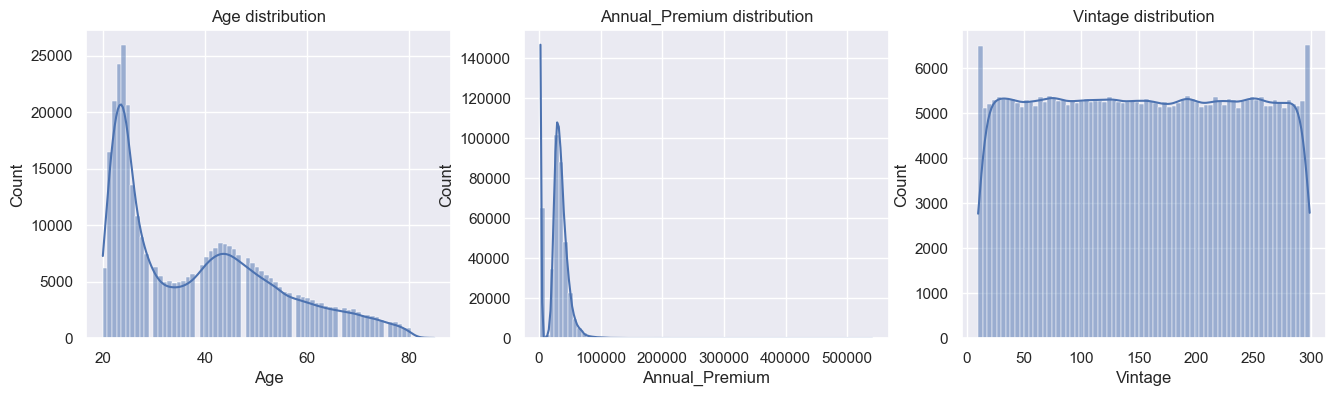

In [8]:
plt.figure(figsize=(16,4))

for i, var in enumerate(cont_var):
    plt.subplot(1, 3, i+1)
    sns.histplot(x =df[var], bins=72, kde=True)
    plt.title(f'{var} distribution')

plt.show()


Both age and the annual premium show skewed distributions, while the vintage variable has a symmetric distribution.

### Categorical variables

We observe the distributions of some categorical variables.

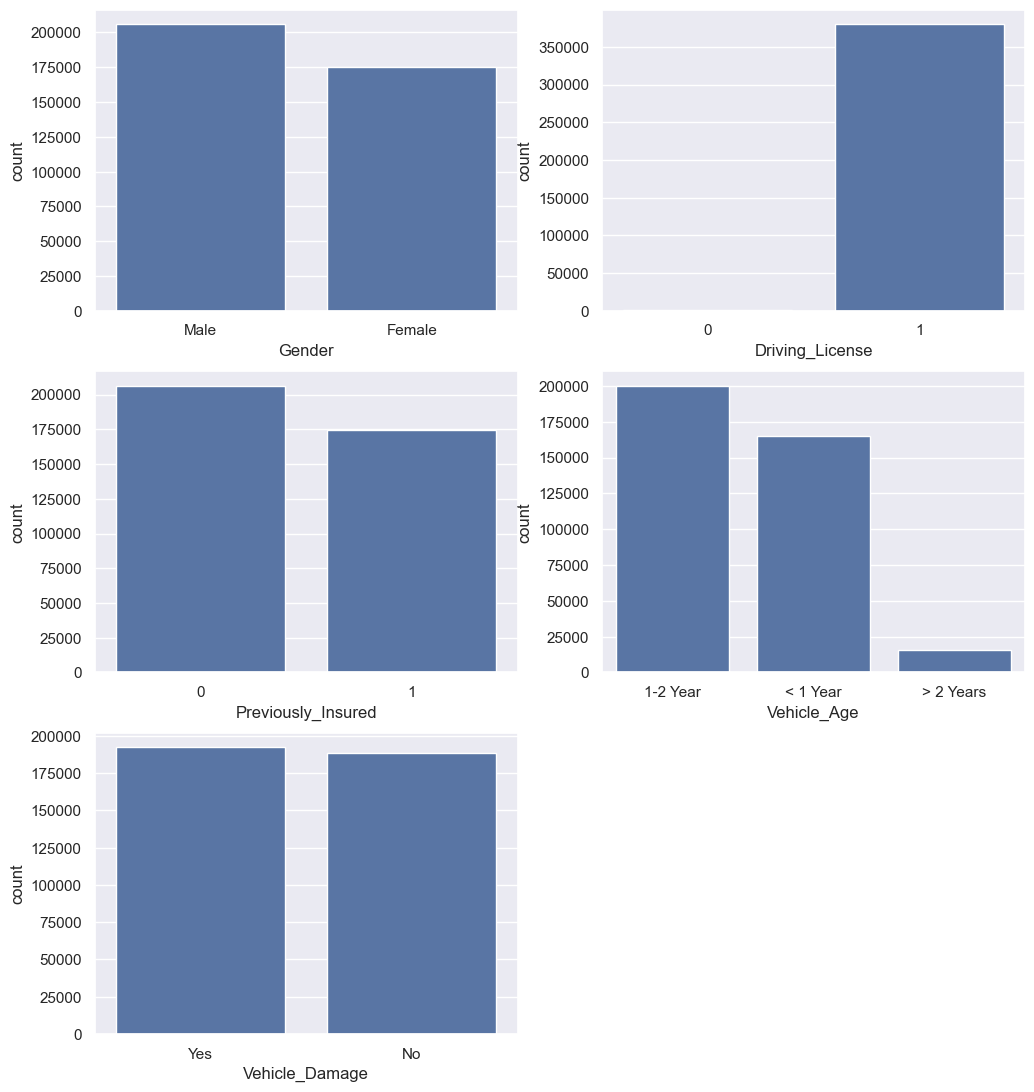

In [9]:
category_var_mask = ['Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage']

plt.figure(figsize=(12,18))

for i,var in enumerate(category_var_mask):
    plt.subplot(4,2,i+1)
    sns.barplot(df[var].value_counts())
plt.show()

The variables Gender, Previously_Insured and Vehicle_Damage are fairly balanced.  
The Driving_License variable is imbalanced, since those who insure a vehicle typically hold a driver's license.  
The Vehicle_Age variable shows a predominance of observations for cars aged 1–2 years, an intermediate number for cars under 1 year old, and few observations for cars older than 2 years.

We now observe the distribution of the Response variable

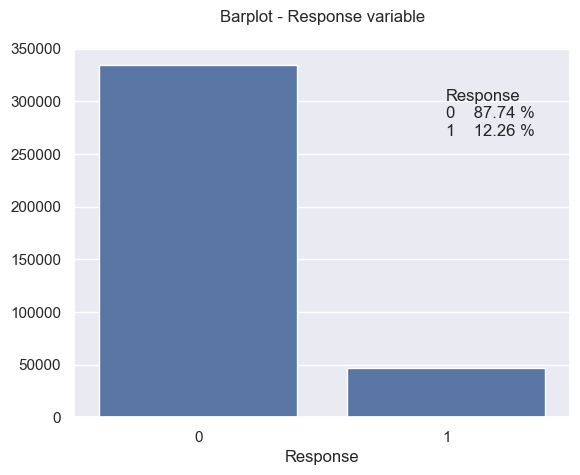

In [10]:
counts = df['Response'].value_counts()
ax = sns.barplot(x=counts.index, y=counts.values)
heights = [patch.get_height() for patch in ax.patches]
plt.text(1, max(heights)*0.8, (round(df['Response'].value_counts()/len(df)*100, 2).map(lambda x: f'{x} %')).to_string())
plt.title("Barplot - Response variable\n")
plt.show()

We can observe the presence of a class imbalance: 88% of the data consists in customers who did not accept the cross-sell offer, while 12% accepted it.

We now examine the distributions of the categorical variables with respect to the response variable "Response".

Count of Gender [%]
---------------------------
Gender
Male      54.1
Female    45.9
Name: proportion, dtype: float64

Count of Gender vs Response
---------------------------
Response     0     1
Gender              
Female    89.6  10.4
Male      86.2  13.8


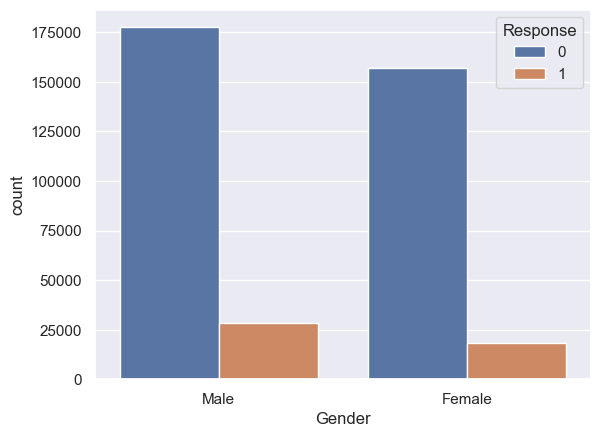

The statistics for the two genders are very similar, with approximately 90% of people not insuring their vehicle and 10% insuring it.
This statistic reflects the imbalance of the Response variable itself.


Count of Driving_License [%]
---------------------------
Driving_License
1    99.8
0     0.2
Name: proportion, dtype: float64

Count of Driving_License vs Response
---------------------------
Response            0     1
Driving_License            
0                95.0   5.0
1                87.7  12.3


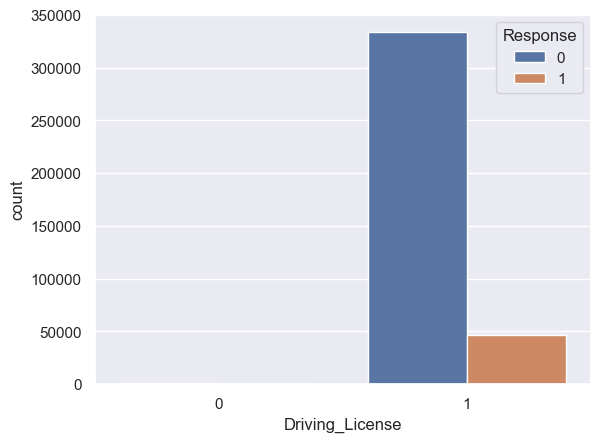

As previously noted (and logically) very few people without a driver's license apply for insurance.
Tra quelli con la patente di guida, invece, also in this case the statistics reflect an 88% positive response for the insurance and 12% negative.


Count of Vehicle_Damage [%]
---------------------------
Vehicle_Damage
Yes    50.5
No     49.5
Name: proportion, dtype: float64

Count of Vehicle_Damage vs Response
---------------------------
Response           0     1
Vehicle_Damage            
No              99.5   0.5
Yes             76.2  23.8


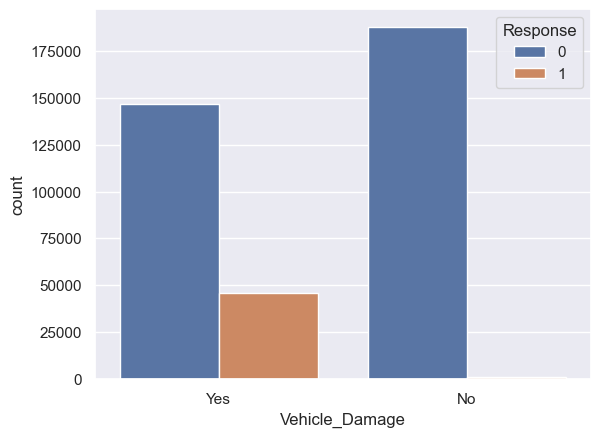

We observe that people who have not had accidents rarely insure their vehicles.
There is therefore a tendency for people with a history of accidents to accept the insurance proposa.


Count of Previously_Insured [%]
---------------------------
Previously_Insured
0    54.2
1    45.8
Name: proportion, dtype: float64

Count of Previously_Insured vs Response
---------------------------
Response               0     1
Previously_Insured            
0                   77.5  22.5
1                   99.9   0.1


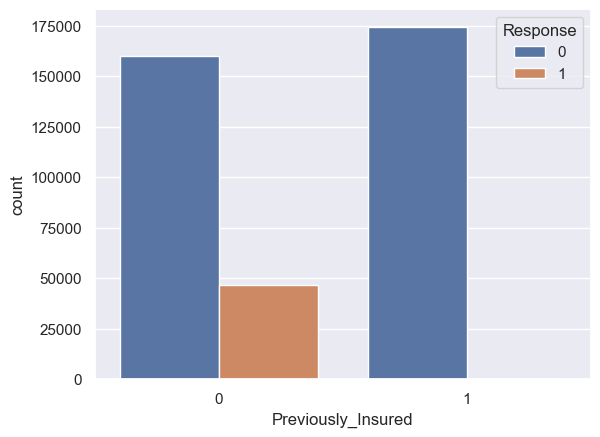

We observe that people who already have an insured vehicle rarely insure another one (only 0.1% of cases).
In this case, therefore, there appears to be a dissonance between the two variables, whereby those who already have an insured vehicle do not accept another insurance proposal.


Count of Vehicle_Age [%]
---------------------------
Vehicle_Age
1-2 Year     52.6
< 1 Year     43.2
> 2 Years     4.2
Name: proportion, dtype: float64

Count of Vehicle_Age vs Response
---------------------------
Response        0     1
Vehicle_Age            
1-2 Year     82.6  17.4
< 1 Year     95.6   4.4
> 2 Years    70.6  29.4


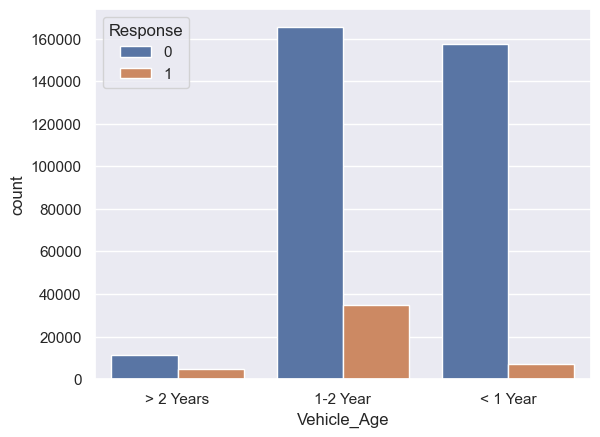

We observe that most people have 1-2 year old vehicles, while very few own vehicles older than 2 years.
However, the highest percentage of insured individuals (29%) is found among owners of vehicles older than 2 years.


In [11]:
categ_counts_response('Gender')
print('The statistics for the two genders are very similar, with approximately 90% of people not insuring their vehicle and 10% insuring it.\n' \
'This statistic reflects the imbalance of the Response variable itself.\n\n')
categ_counts_response('Driving_License')
print("As previously noted (and logically) very few people without a driver's license apply for insurance.\n" \
"Tra quelli con la patente di guida, invece, also in this case the statistics reflect an 88% positive response for the insurance and 12% negative.\n\n")
categ_counts_response('Vehicle_Damage')
print("We observe that people who have not had accidents rarely insure their vehicles.\n" \
"There is therefore a tendency for people with a history of accidents to accept the insurance proposa.\n\n")
categ_counts_response('Previously_Insured')
print("We observe that people who already have an insured vehicle rarely insure another one (only 0.1% of cases).\n\
In this case, therefore, there appears to be a dissonance between the two variables, whereby those who already have an insured vehicle do not accept another insurance proposal.\n\n")
categ_counts_response('Vehicle_Age')
print("We observe that most people have 1-2 year old vehicles, while very few own vehicles older than 2 years.\n\
However, the highest percentage of insured individuals (29%) is found among owners of vehicles older than 2 years.")

We observe the dependence of the annual premium on the response, broken down by vehicle age, using boxplots.

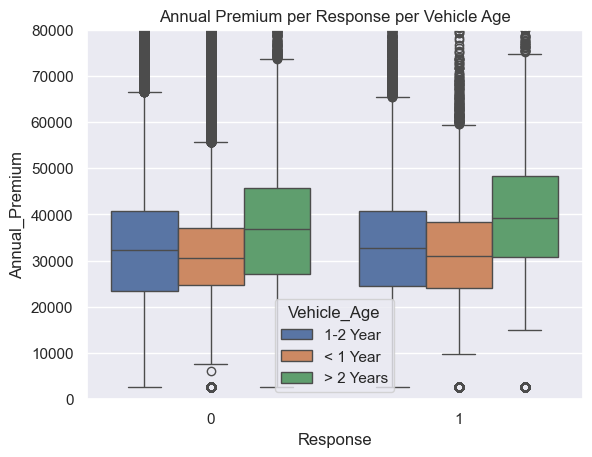

In [12]:
sns.boxplot(x = df['Response'], y= df['Annual_Premium'], hue = df['Vehicle_Age'])
plt.ylim(0,80000)
plt.title("Annual Premium per Response per Vehicle Age")
plt.show()

We do not observe a particular relationship between the annual premium value and acceptance of the cross-sell offer, however there is a tendency toward a higher premium for vehicles older than 2 years.

#### Region_Code and Policy_Sales_Channel variables

We consider the 'Region_Code' variable and observe the % frequencies of the categories in the following table

In [13]:
round((df['Region_Code'].value_counts(normalize=True)*100),1).sort_values(ascending=False).head(10)

Region_Code
28.0    27.9
8.0      8.9
46.0     5.2
41.0     4.8
15.0     3.5
30.0     3.2
29.0     2.9
50.0     2.7
3.0      2.4
11.0     2.4
Name: proportion, dtype: float64

We observe that most people (30%) of customers come from the region with code 28.  
Furthermore, among all insured customers, 42.6% come from this region, as can be seen in the following contingency table.

In [14]:
round(pd.crosstab(df['Region_Code'],df['Response'], normalize='columns')*100, 1).sort_values(by=1, ascending=False).head(10)

Response,0,1
Region_Code,,
28.0,25.9,42.6
8.0,9.2,7.0
41.0,4.8,4.8
46.0,5.3,4.4
29.0,2.9,2.9
3.0,2.4,2.5
11.0,2.4,2.2
15.0,3.7,2.1
30.0,3.4,1.9


We now observe the frequency percentages for the Policy_Sales_Channel variable

In [15]:
round((df['Policy_Sales_Channel'].value_counts(normalize=True)*100),1).sort_values(ascending=False).head(10)

Policy_Sales_Channel
152.0    35.4
26.0     20.9
124.0    19.4
160.0     5.7
156.0     2.8
122.0     2.6
157.0     1.8
154.0     1.6
151.0     1.0
163.0     0.8
Name: proportion, dtype: float64

Most customers were contacted through channels 152, 26 and 124.  
However, from the following contingency table, we observe that most customers who accepted the cross-selling offer come from channels 26 and 124 (together 65% of insured customers), while channel 152 accounts for 8%.

In [16]:
round(pd.crosstab(df['Policy_Sales_Channel'],df['Response'], normalize='columns')*100, 1).sort_values(by=1, ascending=False).head(10)

Response,0,1
Policy_Sales_Channel,,
26.0,19.1,34.0
124.0,17.9,30.0
152.0,39.2,8.3
156.0,2.5,4.9
157.0,1.5,3.8
122.0,2.5,3.7
154.0,1.4,3.2
163.0,0.6,1.9
160.0,6.4,1.0


Since these two variables have a large number of categories, but most samples belong to only a few of them, we decide to keep only the three or four most frequent categories with the strongest link to the response, and group everything else into an "other" category.  

Therefore, for the Region_Code variable, we keep the following categories: 28, 8, 46, 41.  
For the Policy_Sales_Channel variable, we keep the following categories: 26, 124, 152.

In [17]:
cat_region_code = [28.0, 8.0, 46.0, 41.0]
cat_sales_channel = [26.0, 124.0, 152.0]

df['Region_Code_mapped'] = mapping_cat(df['Region_Code'], cat_region_code)
df['Policy_Sales_Channel_mapped'] = mapping_cat(df['Policy_Sales_Channel'], cat_sales_channel)

## Encoding of categorical variables

The following variables need to be encoded: Gender, Vehicle_Age, Vehicle_Damage, Region_Code, Policy_Sales_Channel.

For Gender and Vehicle_Damage, Label Encoding is applied; for Vehicle_Age, Ordinal Encoding is applied; while for Region_Code and Policy_Sales_Channel, One-Hot Encoding is applied.

In [18]:
gender_map = {'Male': 0, 'Female':1}
damage_map = {'No': 0, 'Yes': 1}
age_map = {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}

df['Gender'] = df['Gender'].map(gender_map)
df['Vehicle_Damage'] = df['Vehicle_Damage'].map(damage_map)
df['Vehicle_Age'] = df['Vehicle_Age'].map(age_map)

In [19]:
df = pd.get_dummies(df,columns=['Region_Code_mapped', 'Policy_Sales_Channel_mapped'], dtype=int, prefix = {'Region_Code_mapped': 'RC', 'Policy_Sales_Channel_mapped': 'PSC'})
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,RC_8.0,RC_28.0,RC_41.0,RC_46.0,RC_altro,PSC_26.0,PSC_124.0,PSC_152.0,PSC_altro
0,0,44,1,28.0,0,2,1,40454.0,26.0,217,1,0,1,0,0,0,1,0,0,0
1,0,76,1,3.0,0,1,0,33536.0,26.0,183,0,0,0,0,0,1,1,0,0,0
2,0,47,1,28.0,0,2,1,38294.0,26.0,27,1,0,1,0,0,0,1,0,0,0
3,0,21,1,11.0,1,0,0,28619.0,152.0,203,0,0,0,0,0,1,0,0,1,0
4,1,29,1,41.0,1,0,0,27496.0,152.0,39,0,0,0,1,0,0,0,0,1,0


## Train-test split and scaling

In [20]:
#defining x and y
x = df.drop(['Response','Region_Code','Policy_Sales_Channel'], axis=1)
y = df['Response']

In [21]:
random_seed = 42

In [22]:
#splitting in train and test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=random_seed, stratify=y)

We scaled only the quantitative variables, namely Age, Vehicle_Age, Annual_Premium and Vintage, with the standard scaler, while the encoded categorical variables are left unchanged.

In [23]:
var_to_scale = ['Age', 'Vehicle_Age', 'Annual_Premium', 'Vintage']
ss = StandardScaler()

#splitting numeric and categorical variables for train and test sets
train_num = x_train[var_to_scale]
train_cat = x_train.drop(columns=var_to_scale)

test_num = x_test[var_to_scale]
test_cat = x_test.drop(columns=var_to_scale)

#scaling the numeric variables and construction of the dataframe
train_num_scaled = pd.DataFrame(ss.fit_transform(train_num), columns=var_to_scale, index=x_train.index)
test_num_scaled = pd.DataFrame(ss.transform(test_num), columns=var_to_scale, index=x_test.index)

#concat the dataframe
x_train_scaled = pd.concat([train_num_scaled, train_cat], axis=1)
x_test_scaled = pd.concat([test_num_scaled, test_cat], axis=1)

#column reordering
x_train_scaled = x_train_scaled[x_train.columns]
x_test_scaled = x_test_scaled[x_test.columns]

## Model 1: logistic regression without adjustments

In [24]:
lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
y_pred_train = lr.predict(x_train_scaled)
y_proba_train = lr.predict_proba(x_train_scaled)
y_pred_test = lr.predict(x_test_scaled)
y_proba_test =  lr.predict_proba(x_test_scaled)

print("TRAIN REPORT")
print(classification_report(y_train, y_pred_train))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    234079
           1       0.30      0.00      0.00     32697

    accuracy                           0.88    266776
   macro avg       0.59      0.50      0.47    266776
weighted avg       0.81      0.88      0.82    266776

TEST REPORT
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    100320
           1       0.33      0.00      0.00     14013

    accuracy                           0.88    114333
   macro avg       0.61      0.50      0.47    114333
weighted avg       0.81      0.88      0.82    114333



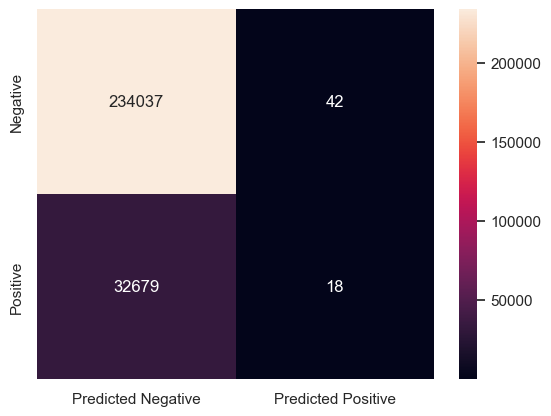

In [26]:
plot_confusion_matrix(y_train, y_pred_train)

This model shows a high accuracy, namely 88%, however recall is practically zero and precision is very low. This is probably a consequence of the highly imbalanced dataset; in fact, as can be seen from the confusion matrix, accuracy is high because the model predicts negatives well, while positives are almost all predicted as negatives, generating a high number of false negatives.  
With a model of this kind, a large number of potentially interested people would be classified as not interested, meaning we might avoid calling them to offer the insurance and thus lose many potential customers.

We therefore try to optimize the model to address the class imbalance and improve recall, in order to better identify customers potentially interested in the offer.

## Model 2: Oversampling

We apply oversampling to the train set to generate synthetic data for the minority class.

In [27]:
oversample = RandomOverSampler(sampling_strategy='minority', random_state=random_seed)

x_over, y_over = oversample.fit_resample(x_train_scaled, y_train)

In [28]:
lr = LogisticRegression()

lr.fit(x_over, y_over)

y_pred_over = lr.predict(x_over)
y_proba_over = lr.predict_proba(x_over)
y_pred_test = lr.predict(x_test)
y_proba_test =  lr.predict_proba(x_test)

print("TRAIN REPORT")
print(classification_report(y_over, y_pred_over))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.94      0.61      0.74    234079
           1       0.71      0.96      0.82    234079

    accuracy                           0.78    468158
   macro avg       0.82      0.78      0.78    468158
weighted avg       0.82      0.78      0.78    468158

TEST REPORT
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    100320
           1       0.00      0.00      0.00     14013

    accuracy                           0.88    114333
   macro avg       0.44      0.50      0.47    114333
weighted avg       0.77      0.88      0.82    114333



Using oversampling, we observe an improvement in performance (with the exception of accuracy) on the train set, however performance drops drastically on the test set, indicating that the model is strongly affected by overfitting.

## Model 3: Undersampling

We apply undersampling to the majority class in order to balance the train set.

In [29]:
undersample = RandomUnderSampler(sampling_strategy='majority', random_state=random_seed)

x_under, y_under = undersample.fit_resample(x_train_scaled, y_train)


In [30]:
lr = LogisticRegression()

lr.fit(x_under, y_under)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
y_pred_under = lr.predict(x_under)
y_proba_under = lr.predict_proba(x_under)
y_pred_test = lr.predict(x_test)
y_proba_test =  lr.predict_proba(x_test)

print("TRAIN REPORT")
print(classification_report(y_under, y_pred_under))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.94      0.61      0.74     32697
           1       0.71      0.96      0.82     32697

    accuracy                           0.79     65394
   macro avg       0.83      0.79      0.78     65394
weighted avg       0.83      0.79      0.78     65394

TEST REPORT
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    100320
           1       0.00      0.00      0.00     14013

    accuracy                           0.88    114333
   macro avg       0.44      0.50      0.47    114333
weighted avg       0.77      0.88      0.82    114333



Also in this case, despite the improvement in test-set accuracy, metrics such as precision and recall are practically zero, making the model unusable for the intended purpose.

## Model 4: Weighted logistic regression

We performed logistic regression by setting the "class_weight" parameter to 'balanced', so as to apply a weight to the classes and achieve a more balanced fit.

In [32]:
lr = LogisticRegression(class_weight='balanced')

lr.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [33]:
y_pred_train = lr.predict(x_train_scaled)
y_proba_train = lr.predict_proba(x_train_scaled)
y_pred_test = lr.predict(x_test_scaled)
y_proba_test =  lr.predict_proba(x_test_scaled)

print("TRAIN REPORT")
print(classification_report(y_train, y_pred_train))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))


TRAIN REPORT
              precision    recall  f1-score   support

           0       0.99      0.61      0.76    234079
           1       0.26      0.96      0.40     32697

    accuracy                           0.65    266776
   macro avg       0.62      0.78      0.58    266776
weighted avg       0.90      0.65      0.71    266776

TEST REPORT
              precision    recall  f1-score   support

           0       0.99      0.61      0.76    100320
           1       0.26      0.96      0.41     14013

    accuracy                           0.66    114333
   macro avg       0.62      0.79      0.58    114333
weighted avg       0.90      0.66      0.71    114333



In this way we obtain a model that is not affected by overfitting, since performance remains practically unchanged when moving from the train set to the test set.  
We also observe a very high recall, indicating that 96% of actual positive subjects, i.e. those potentially interested in the cross-selling offer, are correctly identified.  
Precision, on the other hand, remains low, at 26%, indicating a high number of false positives, as can also be seen from the confusion matrices below.  
This is probably the cause of the 66% accuracy value.

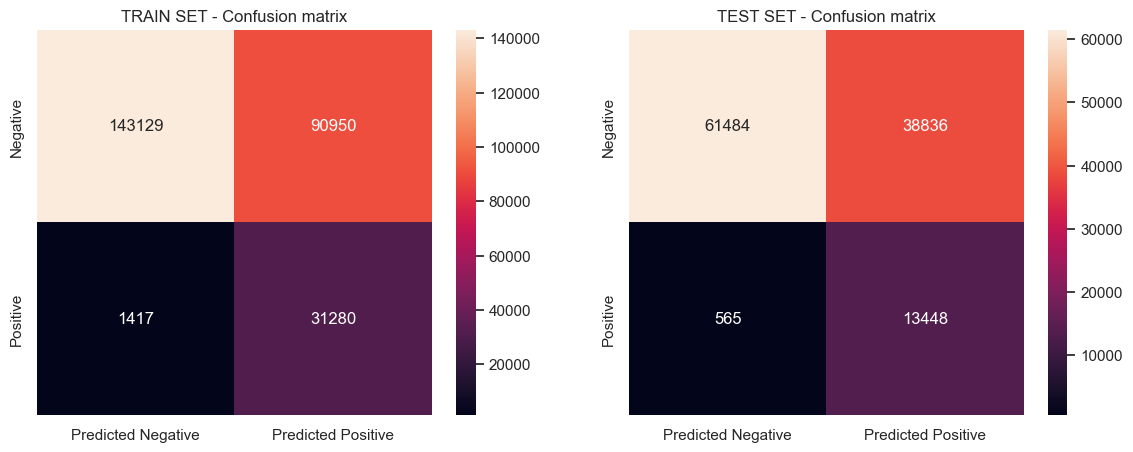

In [34]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plot_confusion_matrix(y_train, y_pred_train)
plt.title('TRAIN SET - Confusion matrix')

plt.subplot(1,2,2)
plot_confusion_matrix(y_test, y_pred_test)
plt.title('TEST SET - Confusion matrix')

plt.show()


## Model 5: Feature selection

We try building the 'balanced' logistic regression model using only the variables found to be most influential for the response.  
Specifically, we select the variables Vehicle_Damage, Previously_Insured, Vehicle_Age and Annual_Premium.

In [35]:
selected_variables = ['Vehicle_Damage', 'Previously_Insured', 'Vehicle_Age', 'Annual_Premium']

x_selected_train = x_train_scaled[selected_variables]
x_selected_test  = x_test_scaled[selected_variables]

In [36]:
x_selected_train

,Vehicle_Damage,Previously_Insured,Vehicle_Age,Annual_Premium
223531,0,1,0.686683,0.230147
337977,0,1,0.686683,0.080331
320307,0,0,0.686683,-1.622764
261303,0,1,-1.075324,-1.622764
71160,0,1,-1.075324,0.019813
...,...,...,...,...
149107,1,0,-1.075324,1.026224
378816,1,1,-1.075324,-0.440252
91744,0,0,-1.075324,1.653454
48700,0,1,0.686683,-0.096175


In [37]:
lr = LogisticRegression(class_weight='balanced')

lr.fit(x_selected_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [38]:
y_pred_train = lr.predict(x_selected_train)
y_proba_train = lr.predict_proba(x_selected_train)
y_pred_test = lr.predict(x_selected_test)
y_proba_test =  lr.predict_proba(x_selected_test)

print("TRAIN REPORT")
print(classification_report(y_train, y_pred_train))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))


TRAIN REPORT
              precision    recall  f1-score   support

           0       0.99      0.59      0.74    234079
           1       0.25      0.98      0.40     32697

    accuracy                           0.64    266776
   macro avg       0.62      0.78      0.57    266776
weighted avg       0.90      0.64      0.70    266776

TEST REPORT
              precision    recall  f1-score   support

           0       0.99      0.59      0.74    100320
           1       0.25      0.98      0.40     14013

    accuracy                           0.64    114333
   macro avg       0.62      0.78      0.57    114333
weighted avg       0.90      0.64      0.70    114333



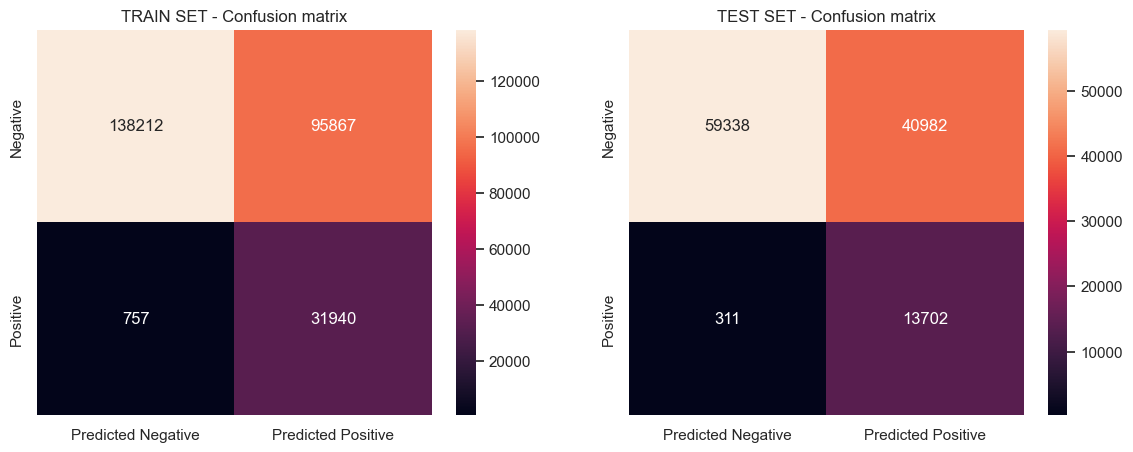

In [39]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plot_confusion_matrix(y_train, y_pred_train)
plt.title('TRAIN SET - Confusion matrix')

plt.subplot(1,2,2)
plot_confusion_matrix(y_test, y_pred_test)
plt.title('TEST SET - Confusion matrix')

plt.show()

With this model, recall improves further by 2%, rising to 98%, without impacting the other metrics too heavily, which drop by only 1 or 2 percentage points.

The model's recall, which represents the number of correctly identified positives, i.e. customers who might be interested, is already very high (98%).  
Precision, on the other hand, is fairly low (25%), indicating that among those classified as positive, only 25% are correct, meaning there are many false positives, i.e. customers the model classifies as interested when they actually are not.

We therefore look for a threshold that tries to optimize precision without affecting recall too much, since we still want to keep it high, as it represents precisely the number of correctly identified interested customers and thus a low number of false negatives.

In [48]:
thresholds = np.arange(0,1.02, 0.02)

results = []

for threshold in thresholds:

    y_proba_train_converted = np.where(y_proba_train[:,1]>= threshold, 1, 0)
    y_proba_test_converted = np.where(y_proba_test[:,1]>= threshold, 1, 0)

    results.append({'threshold': threshold,
        'Accuracy_train': accuracy_score(y_train,y_proba_train_converted),
        'Precision_train': precision_score(y_train,y_proba_train_converted, zero_division=0),
        'Recall_train': recall_score(y_train,y_proba_train_converted),
        'f1_score_train': f1_score(y_train,y_proba_train_converted),
        'Accuracy_test': accuracy_score(y_test,y_proba_test_converted),
        'Precision_test': precision_score(y_test,y_proba_test_converted, zero_division=0),
        'Recall_test': recall_score(y_test,y_proba_test_converted),
        'f1_score_test': f1_score(y_test,y_proba_test_converted)
    })

df_results = pd.DataFrame(results)


We sort the results by the f1_score on the test set, which balances the recall and precision parameters.

In [49]:
round(df_results.sort_values('f1_score_test', ascending=False), 6).head(10)

,threshold,Accuracy_train,Precision_train,Recall_train,f1_score_train,Accuracy_test,Precision_test,Recall_test,f1_score_test
35,0.70,0.717804,0.280235,0.830413,0.419054,0.720133,0.282753,0.835224,0.422481
32,0.64,0.717782,0.280223,0.830443,0.419044,0.720107,0.282743,0.835296,0.422479
34,0.68,0.717804,0.280235,0.830413,0.419054,0.720125,0.282746,0.835224,0.422474
33,0.66,0.717801,0.280232,0.830413,0.419051,0.720125,0.282746,0.835224,0.422474
31,0.62,0.717640,0.280158,0.830749,0.419011,0.719958,0.282659,0.835510,0.422412
30,0.60,0.652139,0.254200,0.950515,0.401125,0.653705,0.255552,0.954185,0.403136
27,0.54,0.637808,0.249908,0.976848,0.397996,0.638836,0.250567,0.977806,0.398911
20,0.40,0.637808,0.249908,0.976848,0.397996,0.638836,0.250567,0.977806,0.398911
24,0.48,0.637808,0.249908,0.976848,0.397996,0.638836,0.250567,0.977806,0.398911
25,0.50,0.637808,0.249908,0.976848,0.397996,0.638836,0.250567,0.977806,0.398911


We also observe the model's ROC curves

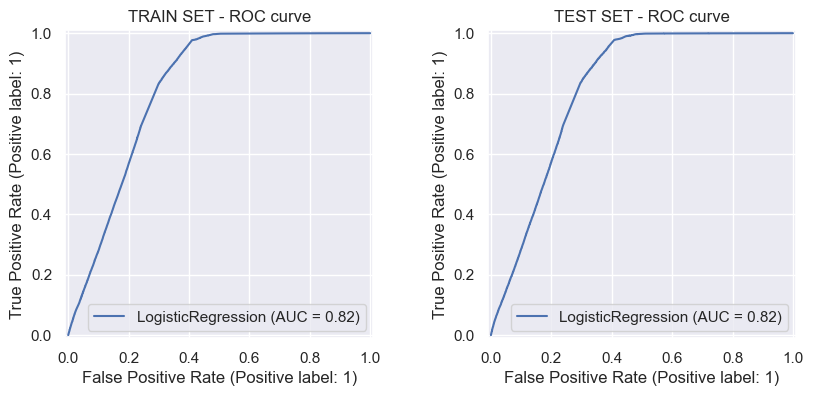

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

RocCurveDisplay.from_estimator(lr,x_selected_train,y_train,ax=ax[0])
ax[0].set_title('TRAIN SET - ROC curve')
RocCurveDisplay.from_estimator(lr, x_selected_test, y_test, ax= ax[1])
ax[1].set_title('TEST SET - ROC curve')
plt.show()


We can observe that the threshold yielding the highest f1_score is 0.7; however, at this value the metrics on the test set are as follows:

- f1_score: 42%
- recall: 83%
- precision: 28%
- accuracy: 72%

If we compare these with those of the model at a threshold of 0.5, we can see that f1_score and precision increase by 2-3% and accuracy by 8%, but at the cost of a 14% decrease in recall.  
We consider that losing 14% of correctly classified positives for a decrease in false negatives of only 3% is not advantageous for the model or for the goal of the study.  
We therefore choose to keep the threshold at 0.5, indeed, even selecting, for example, a threshold of 0.6, where recall only decreases to 95%, precision would still remain at 25% and accuracy would improve by only one percentage point.

We therefore keep the selected model with 98% recall and a threshold of 0.5 (Model 5).

## Cross-Validation

We verify the absence of overfitting in the chosen model through cross-validation

In [43]:
kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

We select only the variables that were chosen for the model

In [44]:
x_selected = x[selected_variables]
x_selected

,Vehicle_Damage,Previously_Insured,Vehicle_Age,Annual_Premium
0,1,0,2,40454.0
1,0,0,1,33536.0
2,1,0,2,38294.0
3,0,1,0,28619.0
4,0,1,0,27496.0
...,...,...,...,...
381104,0,1,1,30170.0
381105,0,1,0,40016.0
381106,0,1,0,35118.0
381107,1,0,2,44617.0


We perform 5-fold cross-validation, splitting the x_selected dataset into 5 folds.  
For each fold, the following pipeline is applied:  
- numeric variables are separated from categorical ones
- scaling is applied to the numeric variables, applying fit_transform on the train set and transform on the test set
- the variables are recombined into a single dataset
- the 'balanced' logistic regression model is run on the train set
- accuracy, recall and precision metrics are computed to evaluate performance on both the train and test sets

In [45]:
kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

train_acc = []
test_acc = []
train_recall = []
test_recall = []
train_prec = []
test_prec = []

for train_index, test_index in kf.split(x):

  x_train_cv, x_test_cv = x.iloc[train_index], x.iloc[test_index]
  y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

  #defining variables to scale
  var_to_scale_cv = ['Vehicle_Age', 'Annual_Premium']

  #splitting in numeric and categorical variables
  train_cv_num = x_train_cv[var_to_scale_cv]
  train_cv_cat = x_train_cv.drop(columns=var_to_scale_cv)

  test_cv_num = x_test_cv[var_to_scale_cv]
  test_cv_cat = x_test_cv.drop(columns=var_to_scale_cv)

  #scaling numeric variables
  ss = StandardScaler()
  train_cv_num_scaled = pd.DataFrame(ss.fit_transform(train_cv_num), columns=var_to_scale_cv, index= x_train_cv.index)
  test_cv_num_scaled = pd.DataFrame(ss.transform(test_cv_num), columns=var_to_scale_cv, index=x_test_cv.index)

  #concat the dataframes
  x_train_cv_scaled = pd.concat([train_cv_num_scaled, train_cv_cat], axis=1)
  x_test_cv_scaled = pd.concat([test_cv_num_scaled, test_cv_cat], axis=1)

  #reordering the columns
  x_train_cv_scaled = x_train_cv_scaled[x_train_cv.columns]
  x_test_cv_scaled = x_test_cv_scaled[x_test_cv.columns]

  #fitting the model
  lr = LogisticRegression(class_weight = 'balanced')
  lr.fit(x_train_cv_scaled, y_train_cv)

  #calculating the metrics for train and test sets
  acc_train = accuracy_score(y_train_cv, lr.predict(x_train_cv_scaled))
  acc_test = accuracy_score(y_test_cv, lr.predict(x_test_cv_scaled))
  recall_train = recall_score(y_train_cv, lr.predict(x_train_cv_scaled))
  recall_test = recall_score(y_test_cv, lr.predict(x_test_cv_scaled))
  prec_train = precision_score(y_train_cv, lr.predict(x_train_cv_scaled))
  prec_test = precision_score(y_test_cv, lr.predict(x_test_cv_scaled))

  train_acc.append(acc_train)
  test_acc.append(acc_test)
  train_recall.append(recall_train)
  test_recall.append(recall_test)
  train_prec.append(prec_train)
  test_prec.append(prec_test)

#creating a dictionary with the cv results
cv_results = {
      "train_accuracy":np.array(train_acc),
      "test_accuracy":np.array(test_acc),
      "train_recall": np.array(train_recall),
      "test_recall": np.array(test_recall),
      "train_precision": np.array(train_prec),
      "test_precision": np.array(test_prec)
    }

In [46]:
cv_results

{'train_accuracy': array([0.6694677 , 0.666237  , 0.66802127, 0.67854648, 0.6710005 ]),
 'test_accuracy': array([0.6732833 , 0.6667104 , 0.66568707, 0.67834746, 0.66841159]),
 'train_recall': array([0.93876892, 0.94321192, 0.94282808, 0.92592888, 0.93839852]),
 'test_recall': array([0.93898981, 0.94166756, 0.93924484, 0.9286496 , 0.93865555]),
 'train_precision': array([0.26167846, 0.26130053, 0.26227616, 0.26758093, 0.26343201]),
 'test_precision': array([0.26881914, 0.26140179, 0.26060246, 0.26231028, 0.26231222])}

We compute the average of the metrics across the 5 folds and build the following summary table

In [47]:
cv_results_mean = pd.DataFrame()
cv_results_mean['Metric'] = ['Accuracy', 'Recall', 'Precision']
cv_results_mean['Train_cv_results'] = [cv_results['train_accuracy'].mean(), cv_results['train_recall'].mean(), cv_results['train_precision'].mean()]
cv_results_mean['Test_cv_results'] = [cv_results['test_accuracy'].mean(), cv_results['test_recall'].mean(), cv_results['test_precision'].mean()]
cv_results_mean = round(cv_results_mean, 4)
cv_results_mean

,Metric,Train_cv_results,Test_cv_results
0,Accuracy,0.6707,0.6705
1,Recall,0.9378,0.9374
2,Precision,0.2633,0.2631


The results confirm the absence of overfitting in the chosen model, as performance remains similar across all train and test sets.  
The model can therefore be considered valid.

## Conclusions

A logistic regression model was built, capable of identifying customers potentially interested in an insurance cross-selling offer.  
The model is particularly well-suited to avoid losing potentially interested customers, at the cost of mistakenly including some customers who might not be.  
In particular, the analysis showed that the most interested customers are likely to be those with vehicles older than 2 years who do not already have an insured vehicle and/or who have had accidents in the past. Furthermore, it is recommended to continue investing in particular in communication channels 26 and 124, and in the region with code 28.